# GLFTMM Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [1]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [ ]:
with open(REPO_ROOT / "config/config.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

ROOT_DIR = Path(CONFIG["paths"]["output_dir"])
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 600

# Cap points sent to matplotlib per run after EVERY sampling. Use None to disable.
MAX_PLOT_POINTS = 50_000

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

(PosixPath('/data/users/kang/backtest/glftmm/result'), 'BTCUSDT')

Discover every leaf folder that contains matching parquet reports.

In [3]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

found 12 folders under /data/users/kang/backtest/glftmm/result


,run_id,run_name,file_count,folder
0,0,sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0__md0__ink__oc5x5x1__obo10000__po1_...,9,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...
1,1,sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0__md1__ink__oc5x5x1__obo10000__po1_...,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...
2,2,sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0p1__md0__ink__oc5x5x1__obo10000__po...,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...
3,3,sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0p1__md1__ink__oc5x5x1__obo10000__po...,11,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...
4,4,sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0p5__md0__ink__oc5x5x1__obo10000__po...,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...
5,5,sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0p5__md1__ink__oc5x5x1__obo10000__po...,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...
6,6,sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0__md0__ink__oc5x5x1__obo10000__po1__pp1...,11,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...
7,7,sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0__md1__ink__oc5x5x1__obo10000__po1__pp1...,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...
8,8,sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0p1__md0__ink__oc5x5x1__obo10000__po1__p...,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...
9,9,sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0p1__md1__ink__oc5x5x1__obo10000__po1__p...,10,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...


Helper functions for selecting folders and calling `report_tools.report(...)`.

In [4]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
    max_plot_points: int | None = MAX_PLOT_POINTS,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
        max_plot_points=max_plot_points,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

batch 1: run_id 000..005


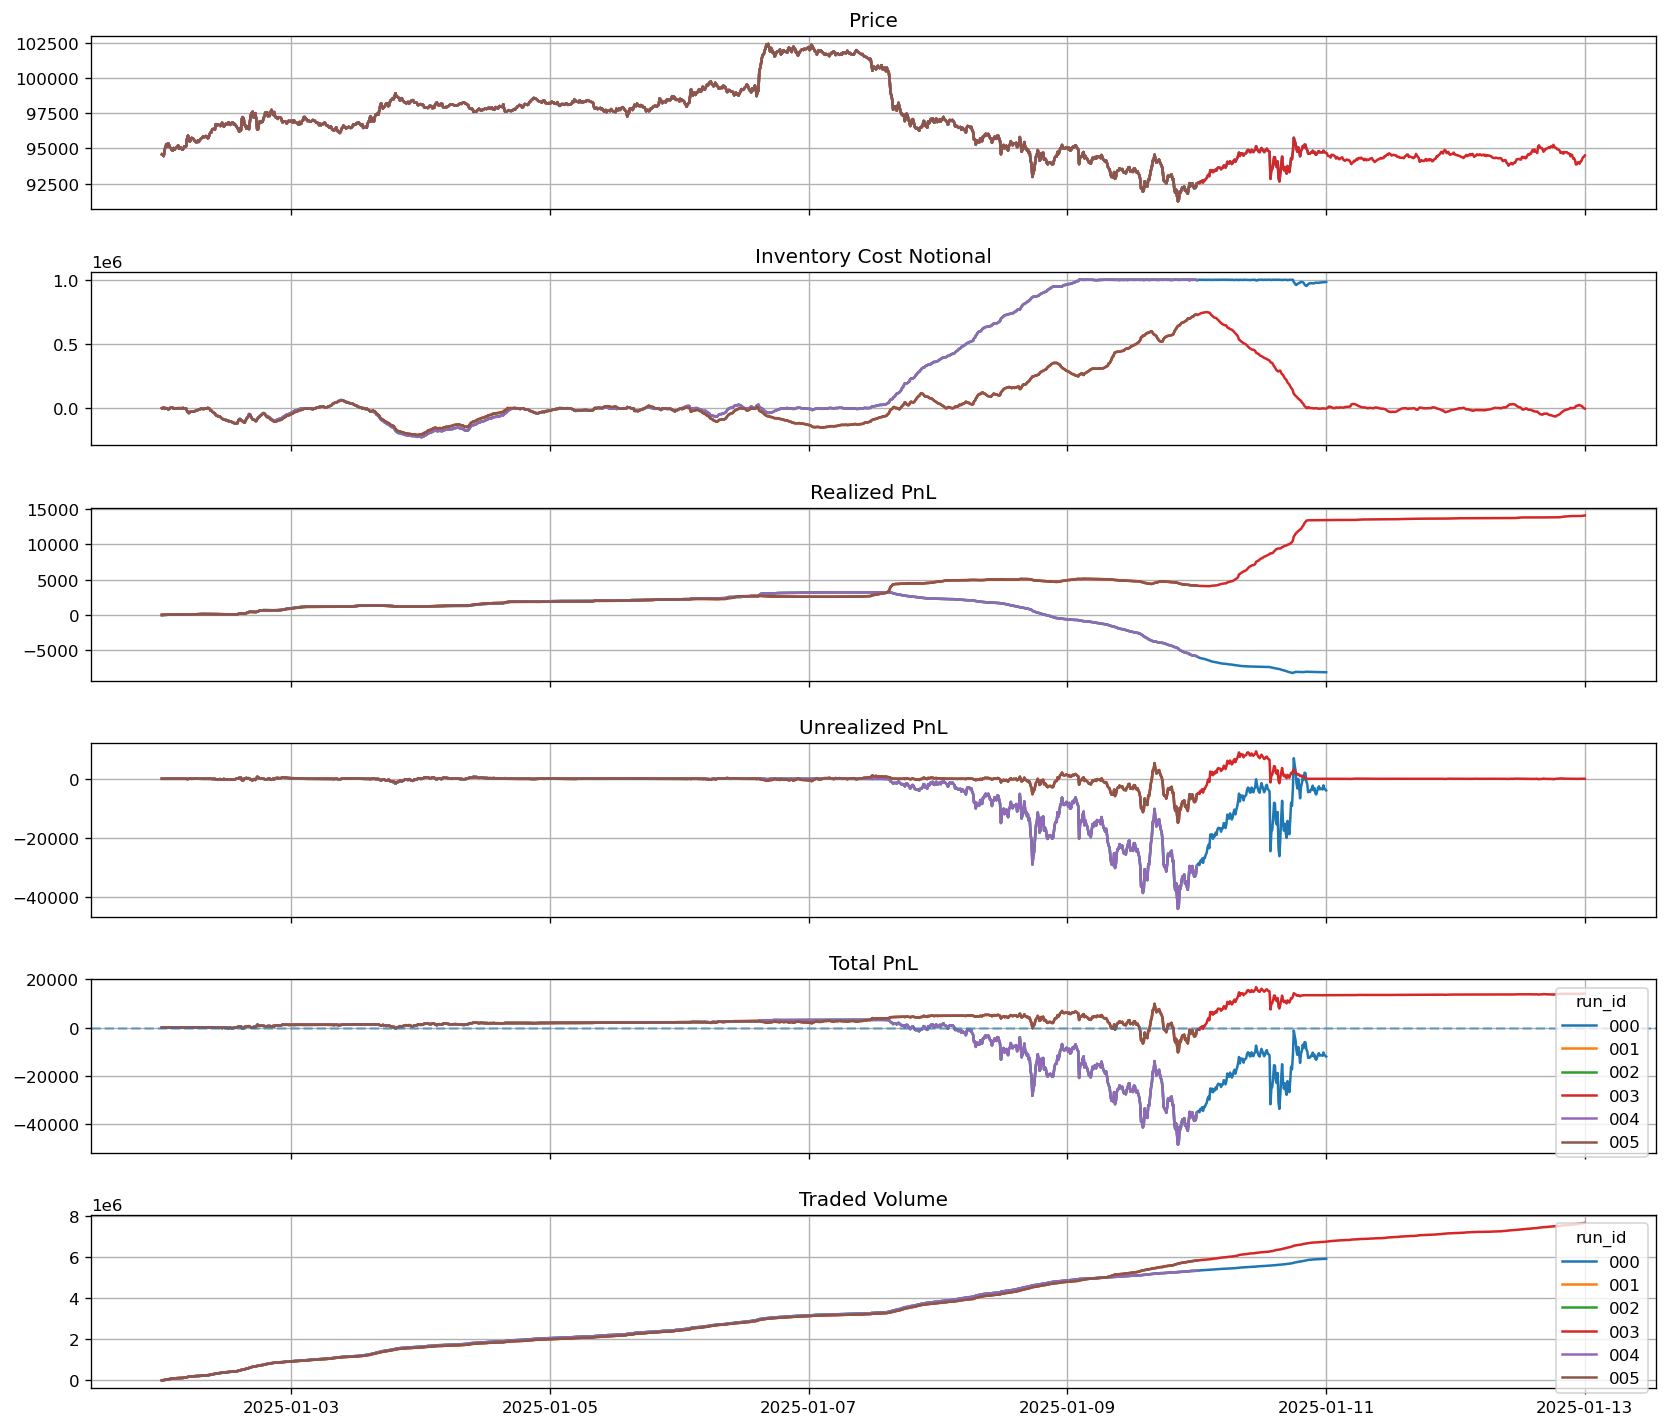

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,9,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-12039.612911,-0.120122,-15.605666,38454.398156,-6.001065e+05,-15.605666,-0.120122,621914.447850,-0.002040
1,001,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-1131.517476,-0.098866,-16.052612,7286.528804,-1.169678e+05,-16.052612,-0.098866,699267.252071,-0.000195
2,002,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-35312.041971,-0.519566,-49.391670,38454.398156,-1.899327e+06,-49.391670,-0.519566,627672.907143,-0.006637
3,003,11,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,14094.370417,0.241870,65.033358,7286.528804,4.738674e+05,65.033358,0.241870,672334.968450,0.001844
4,004,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-35312.123626,-0.519568,-49.391781,38454.398156,-1.899331e+06,-49.391781,-0.519568,627393.596571,-0.006639
5,005,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-1135.582323,-0.099052,-16.081700,7286.528804,-1.171798e+05,-16.081700,-0.099052,698765.120629,-0.000195


batch 2: run_id 006..011


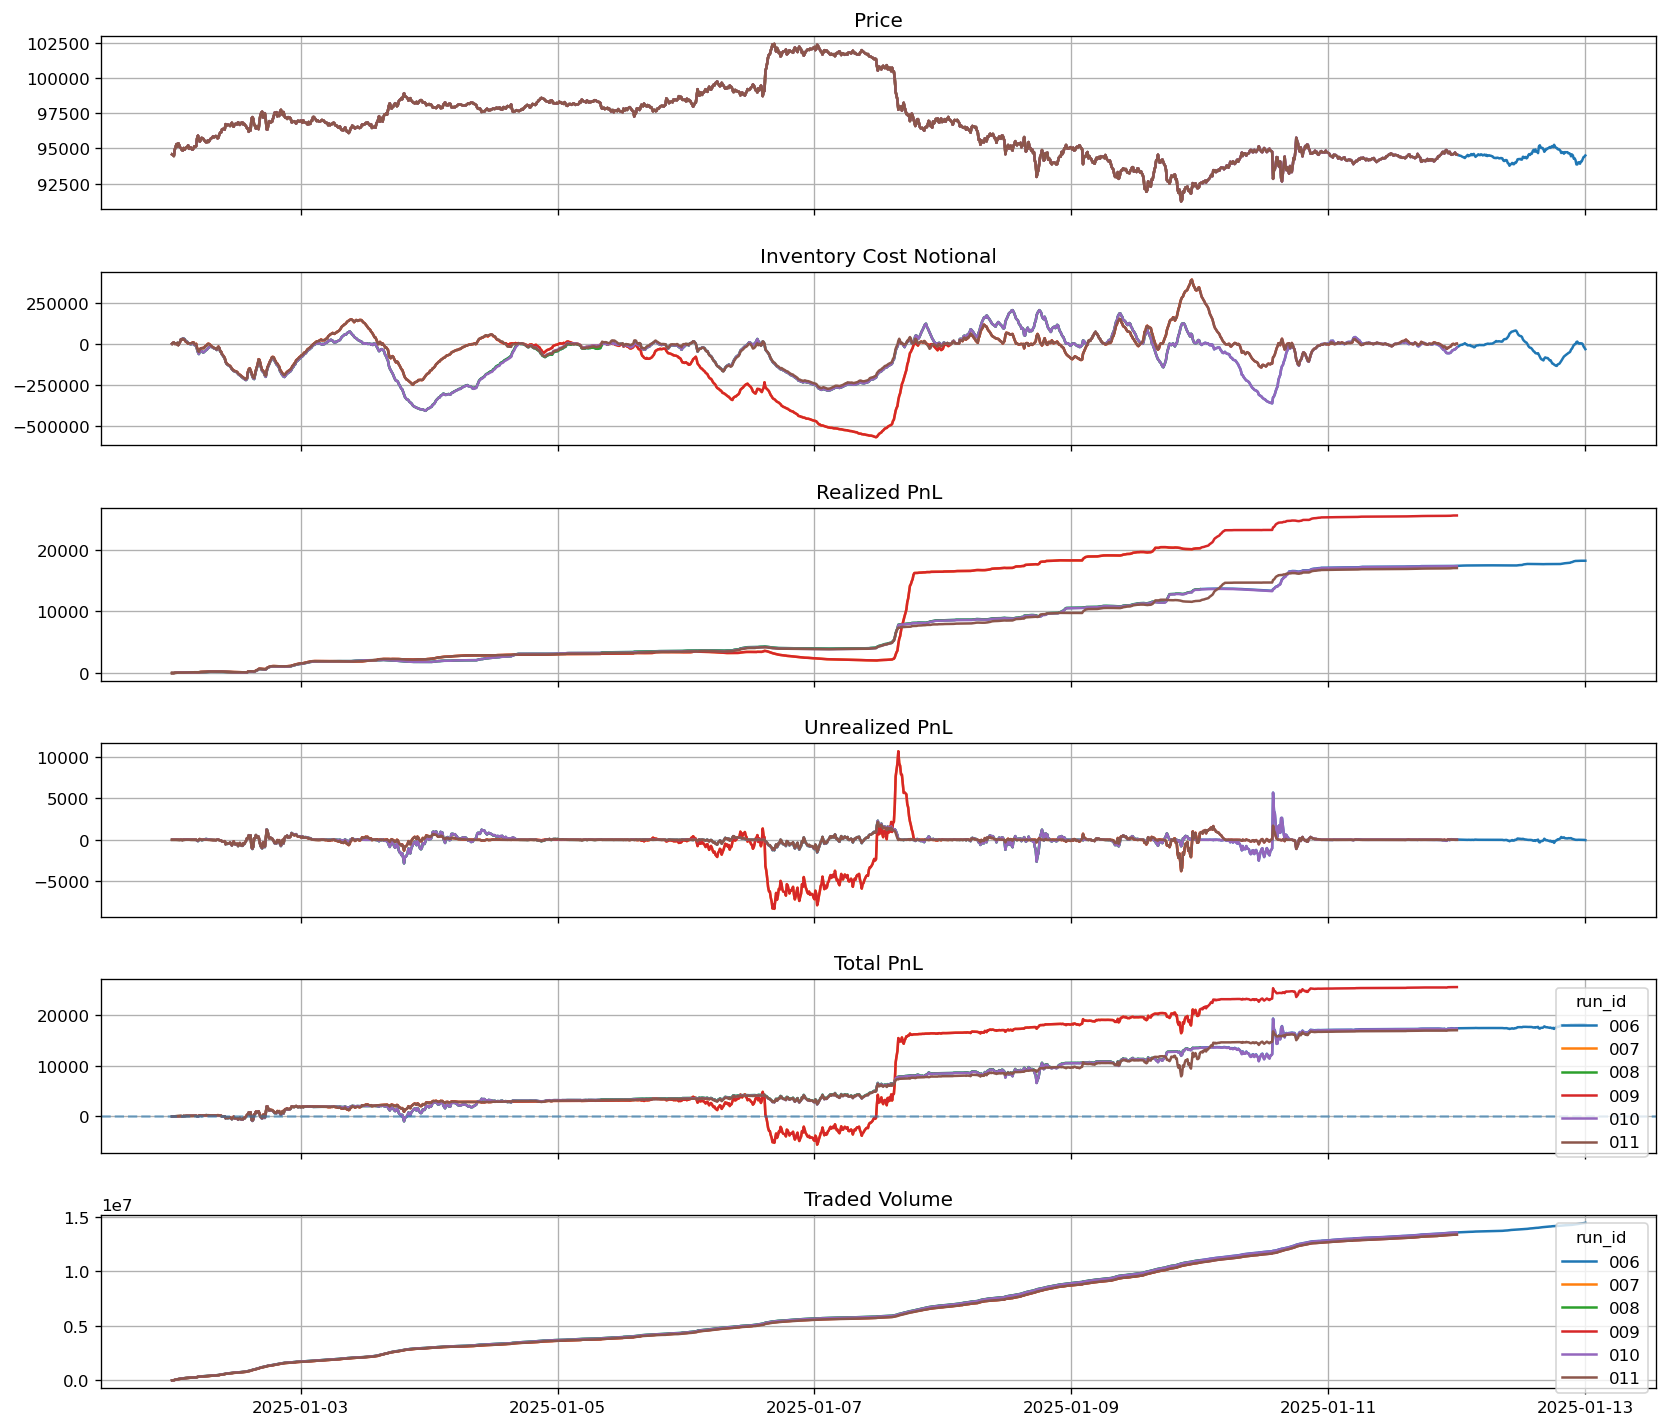

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,006,11,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,18140.273147,0.828535,736.259120,808.424309,595209.770680,736.259120,0.828535,1.270003e+06,0.001257
1,007,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,21015.784446,0.306724,121.561783,8218.420986,999045.911772,121.561783,0.306724,1.298358e+06,0.001948
2,008,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,13591.284095,0.763482,758.391824,808.424309,613102.386126,758.391824,0.763482,1.324843e+06,0.001235
3,009,10,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,25509.195624,0.337267,116.721752,8218.420986,959268.495823,116.721752,0.337267,1.295349e+06,0.001909
4,010,10,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,17335.373231,0.830799,777.686939,808.424309,628701.026362,777.686939,0.830799,1.312537e+06,0.001280
5,011,10,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,16999.224423,0.852687,889.535099,690.407705,614141.885977,889.535099,0.852687,1.294715e+06,0.001273


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,009,10,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,25509.195624,0.337267,116.721752,8218.420986,9.592685e+05,116.721752,0.337267,1.295349e+06,0.001909
1,007,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,21015.784446,0.306724,121.561783,8218.420986,9.990459e+05,121.561783,0.306724,1.298358e+06,0.001948
2,006,11,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,18140.273147,0.828535,736.259120,808.424309,5.952098e+05,736.259120,0.828535,1.270003e+06,0.001257
3,010,10,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,17335.373231,0.830799,777.686939,808.424309,6.287010e+05,777.686939,0.830799,1.312537e+06,0.001280
4,011,10,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,16999.224423,0.852687,889.535099,690.407705,6.141419e+05,889.535099,0.852687,1.294715e+06,0.001273
5,003,11,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,14094.370417,0.241870,65.033358,7286.528804,4.738674e+05,65.033358,0.241870,6.723350e+05,0.001844
6,008,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__mo...,13591.284095,0.763482,758.391824,808.424309,6.131024e+05,758.391824,0.763482,1.324843e+06,0.001235
7,001,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-1131.517476,-0.098866,-16.052612,7286.528804,-1.169678e+05,-16.052612,-0.098866,6.992673e+05,-0.000195
8,005,8,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-1135.582323,-0.099052,-16.081700,7286.528804,-1.171798e+05,-16.081700,-0.099052,6.987651e+05,-0.000195
9,000,9,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,-12039.612911,-0.120122,-15.605666,38454.398156,-6.001065e+05,-15.605666,-0.120122,6.219144e+05,-0.002040


In [5]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

In [6]:
folders[4]

'/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk20x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100__moq0__mqdb0p5__md0__ink__oc5x5x1__obo10000__po1__pp1__qp3__sm1__sl50000__stm0__tf0p00025/strat__all'

Inspect one folder with the full report panels.

Compare selected folders on one PnL chart.